# T44 — End-Permian CO₂-sensitivity ensemble

*Based on:* a PLASIM-GENIE 252 Ma CO₂ ensemble computed by A. Merdith for this study.

**Climate response of the end-Permian (252 Ma) world to a CO₂ sweep across two orders of magnitude. Loads the compact stacked PLASIM-GENIE output bundled with the suite, plots surface-air temperature at three representative CO₂ levels, the zonal-mean SAT-vs-latitude fan coloured by CO₂, and the global-mean GAST-vs-CO₂ sensitivity curve.**

## What this notebook produces

PLASIM-GENIE (PLASIM atmosphere + GOLDSTEIN ocean, run by Merdith *et al.*) was run at the 252 Ma paleogeography for ten CO₂ concentrations from 140 to 35840 ppm — pre-industrial to a runaway end-Permian scenario. This notebook reproduces the headline science figure (3-panel SAT map across three CO₂ levels), the latitudinal temperature-profile fan (one curve per CO₂), and the global climate-sensitivity scatter (GAST vs ln-CO₂ with regression slope) from a compact bundled NetCDF — versus the 1.5 GB of raw model output the full ensemble produces.

**Audience**: postgrad → researcher.
**Difficulty**: ★★★.

## Learning objectives

- Load a multi-CO₂ stacked NetCDF (dims `co2_ppm × lat × lon`) with `xarray` and select snapshots by CO₂.
- Compute area-weighted global-mean surface temperature (GAST) under a `cos(latitude)` weight.
- Render a SAT map with pyGMT `grdimage` using a custom diverging palette appropriate for the −40 to +40 °C range.
- Fit a logarithmic climate-sensitivity curve (ΔGAST per CO₂ doubling) from the ensemble.

## Prerequisites and runtime

- **Data**: `data/plasim_genie_permian/plasim_genie_252Ma_equilibrium.nc` (bundled, 350 KB).
- **Python**: `xarray`, `pygmt`, `numpy`, `matplotlib`, `cmcrameri`.
- **Runtime**: ~30 seconds.

*PLASIM-GENIE model: Holden et al. (2016), <https://doi.org/10.5194/gmd-9-3347-2016>

## Data availability

This notebook reads the compact `data/plasim_genie_permian/plasim_genie_252Ma_equilibrium.nc` bundle, produced by stripping the last-year (year 3000) snapshot from each of Andrew Merdith's ten 252 Ma PLASIM-GENIE runs and stacking on a `co2_ppm` axis. Full model output (1.5 GB, 30 yearly snapshots per CO₂ level, all 100+ PLASIM variables) is available from Andrew Merdith on request.

> Holden, P.B., Edwards, N.R., Fraedrich, K., Kirk, E., Lunkeit, F. & Zhu, X. (2016). PLASIM–GENIE v1.0: a new intermediate complexity AOGCM. *Geoscientific Model Development* 9, 3347–3361. https://doi.org/10.5194/gmd-9-3347-2016

End-Permian 252 Ma ensemble: bundled with this tutorial collection (see `data/plasim_genie_permian/README.md`).

In [1]:
# Defensive cwd fix: when Jupyter runs this notebook from Notebooks/, the
# `data/...` relative paths used below would not resolve. Step up to the
# suite root once so every `data/...` literal in the rest of the notebook
# finds its file. Idempotent — only runs if `../data` exists and `./data`
# doesn't.
import os as _os
import sys as _sys
from pathlib import Path as _Path
if _Path("../data").exists() and not _Path("data").exists():
    _os.chdir("..")

# Imports
import numpy as np, xarray as xr
import pygmt
import matplotlib.pyplot as plt
from cmcrameri import cm as cmc
from IPython.display import display, HTML

# Shared display helpers live in Notebooks/paleoclimate_helpers.py; make that
# directory importable regardless of where the kernel was launched.
_NB_DIR = str(_Path("Notebooks").resolve()) if _Path("Notebooks").is_dir() else str(_Path.cwd())
if _NB_DIR not in _sys.path:
    _sys.path.insert(0, _NB_DIR)
from paleoclimate_helpers import refine_for_plot

# Library versions (printed for reproducibility)
print(f"pygmt {pygmt.__version__}  xarray {xr.__version__}  numpy {np.__version__}")

pygmt v0.19.0  xarray 2026.7.0  numpy 2.5.1


## Configuration

In [2]:
# === USER CONFIGURATION =====================================================
CLIMATE_NC           = "data/plasim_genie_permian/plasim_genie_252Ma_equilibrium.nc"
MODEL_NAME           = "PLASIM-GENIE"
RECONSTRUCTION_TIME  = 252.0          # Ma — end-Permian
CO2_PANEL_VALUES     = (280, 1120, 17920)   # ppm — three representative scenarios
SAT_RANGE            = (-40, 40)      # °C — colour-bar limits
# ============================================================================

## 1. Load the compact bundle

In [3]:
# Load the compact bundle
ds = xr.open_dataset(CLIMATE_NC)
print(ds)
print(f"\nCO2 levels: {ds.co2_ppm.values.tolist()} ppm")

# Shared plot styling: one colour per CO2 level (used by every panel below)
base = cmc.batlowK
norm_levels = np.linspace(0, 1, len(ds.co2_ppm))

<xarray.Dataset> Size: 820kB
Dimensions:            (co2_ppm: 10, latitude: 32, longitude: 64)
Coordinates:
  * co2_ppm            (co2_ppm) int32 40B 140 280 560 1120 ... 8960 17920 35840
  * latitude           (latitude) float32 128B 85.76 80.27 ... -80.27 -85.76
  * longitude          (longitude) float32 256B 0.0 5.625 11.25 ... 348.8 354.4
Data variables:
    SAT                (co2_ppm, latitude, longitude) float32 82kB ...
    surface_T          (co2_ppm, latitude, longitude) float32 82kB ...
    sea_ice_cover      (co2_ppm, latitude, longitude) float32 82kB ...
    sea_ice_thickness  (co2_ppm, latitude, longitude) float32 82kB ...
    snow_depth         (co2_ppm, latitude, longitude) float32 82kB ...
    surface_albedo     (co2_ppm, latitude, longitude) float32 82kB ...
    landsea_mask       (co2_ppm, latitude, longitude) float32 82kB ...
    orography          (co2_ppm, latitude, longitude) float32 82kB ...
    top_thermal        (co2_ppm, latitude, longitude) float32 82kB ...

## 2. Model spin-up — equilibrium check

Before trusting the last-year snapshot, confirm every run reached equilibrium.
The GAST and thermal-outgoing curves should flatten by ~year 1500 for every CO₂ level.

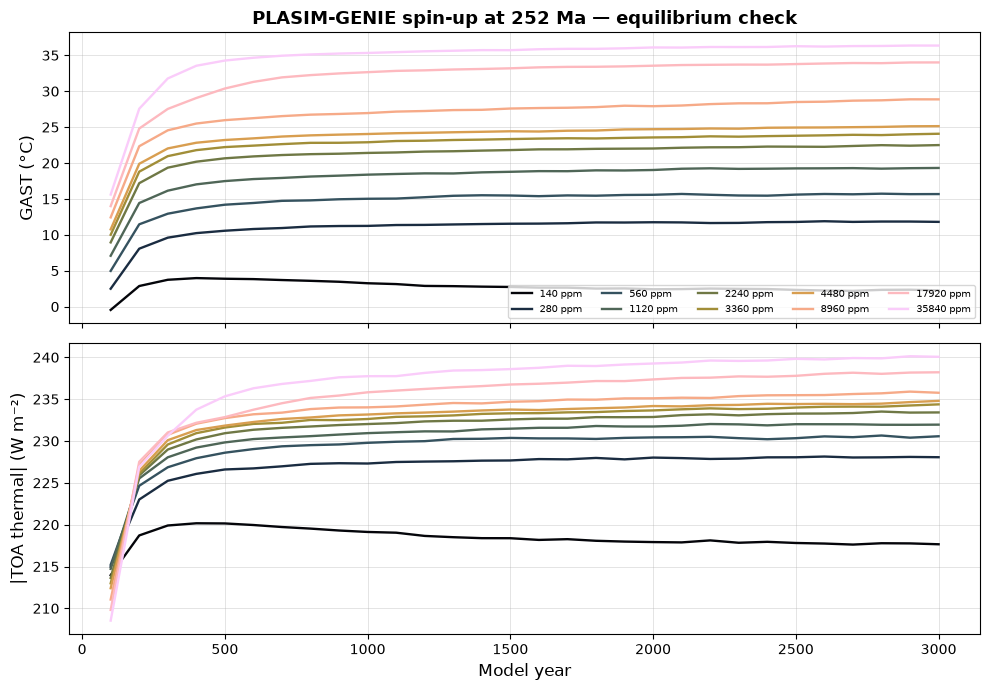

In [4]:
# Spin-up curves — energy-balance time series (equilibrium check)
sp = xr.open_dataset("data/plasim_genie_permian/plasim_genie_252Ma_spinup.nc")

# The bundled spin-up scalars are area-weighted global means that were summed
# over longitude but never divided by the number of longitudes, so they come
# out a factor n_lon (= 64) too large. Normalise so GAST is in °C (and matches
# the equilibrium GAST computed in §5) and |TOA thermal| is a genuine W m⁻² flux.
n_lon = ds.sizes["longitude"]
gast_sp    = sp["GAST"] / n_lon
thermal_sp = sp["top_thermal_abs"] / n_lon

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
for i, co2 in enumerate(sp.co2_ppm.values):
    color = base(norm_levels[i])
    axes[0].plot(sp.year, gast_sp.isel(co2_ppm=i),    lw=1.7, color=color, label=f"{co2} ppm")
    axes[1].plot(sp.year, thermal_sp.isel(co2_ppm=i), lw=1.7, color=color)
axes[0].set_ylabel("GAST (°C)", fontsize=12); axes[0].grid(True, lw=0.4, alpha=0.6)
axes[1].set_ylabel("|TOA thermal| (W m⁻²)", fontsize=12); axes[1].grid(True, lw=0.4, alpha=0.6)
axes[1].set_xlabel("Model year", fontsize=12)
axes[0].set_title(f"PLASIM-GENIE spin-up at {RECONSTRUCTION_TIME:.0f} Ma — equilibrium check",
                  fontsize=13, fontweight="bold")
axes[0].legend(loc="lower right", ncol=5, fontsize=7, frameon=True)
plt.tight_layout(); plt.show()

## 3. Per-CO₂ surface-air temperature maps (3-panel)

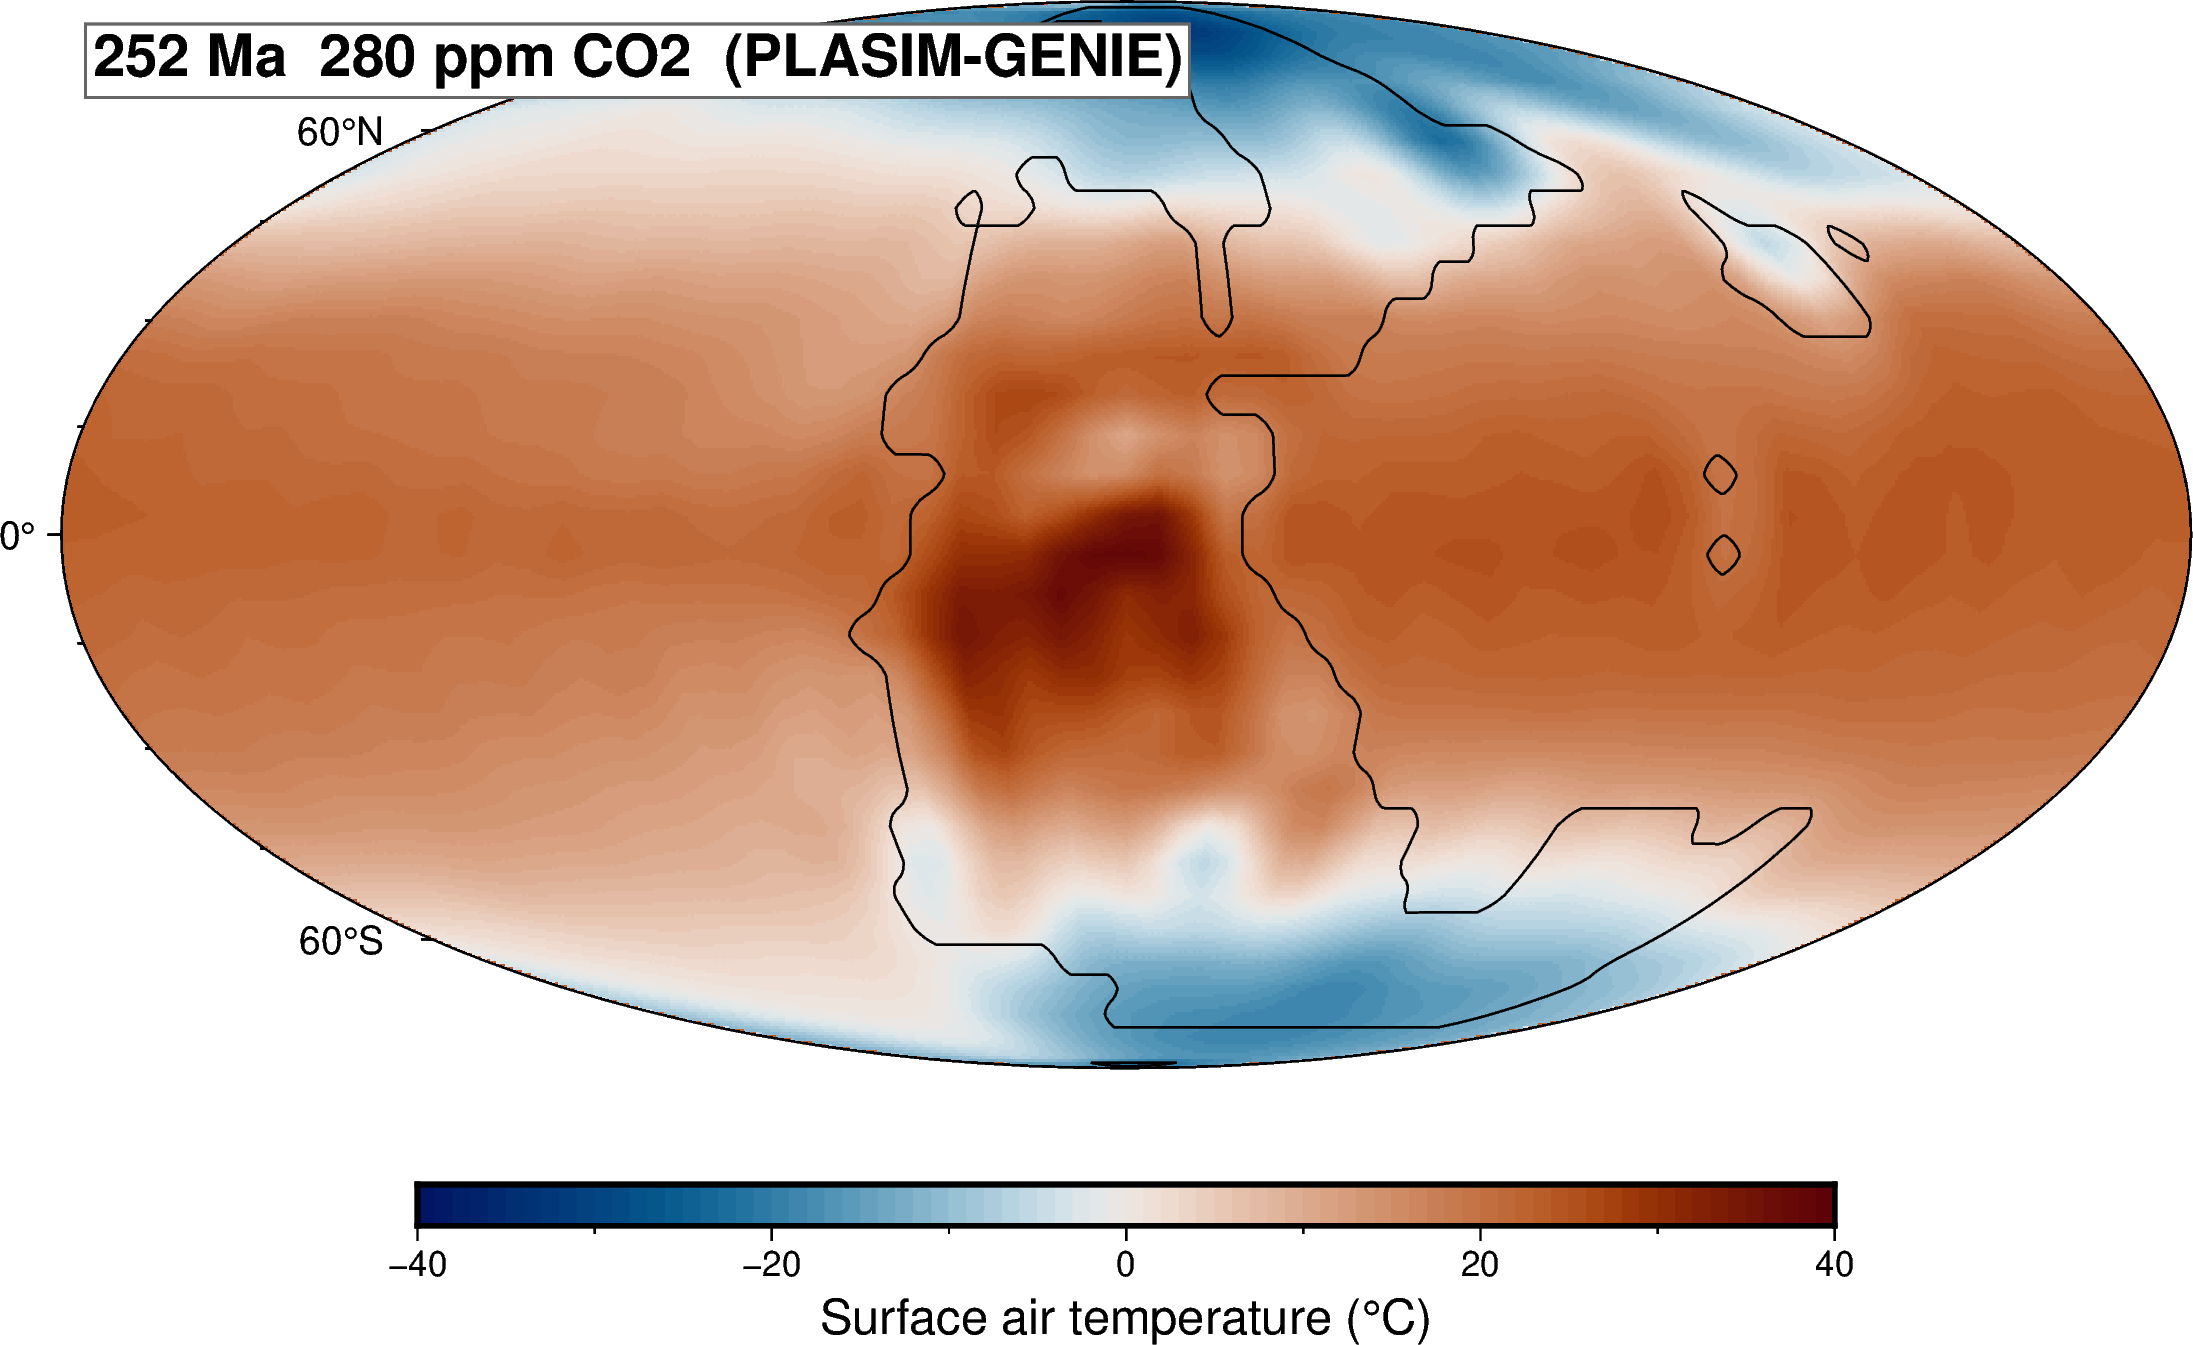

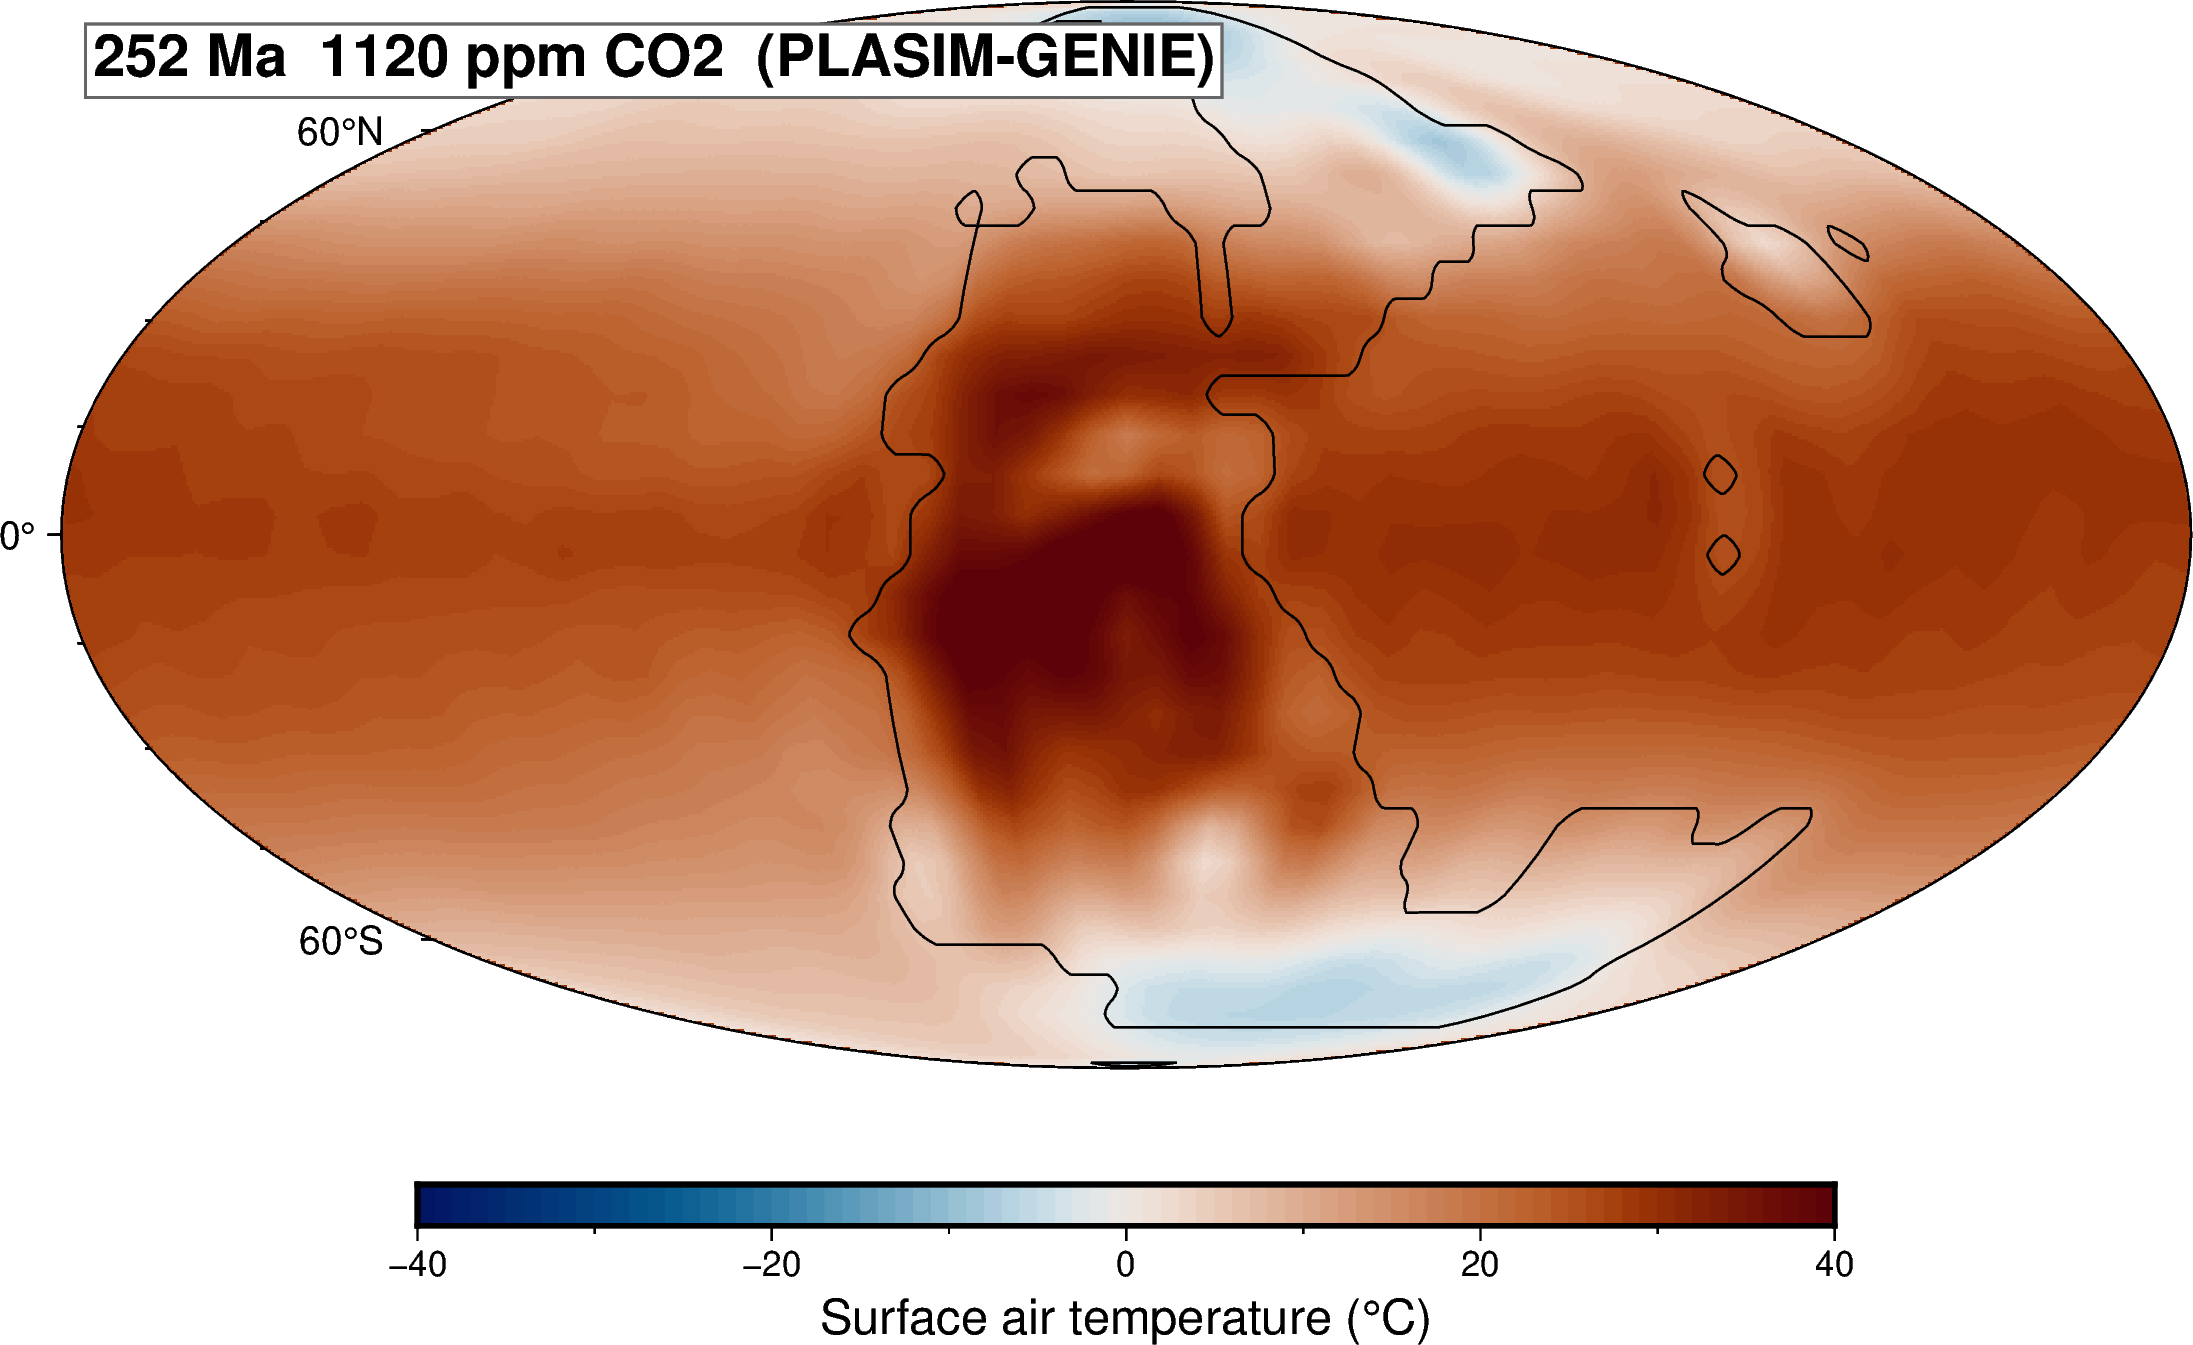

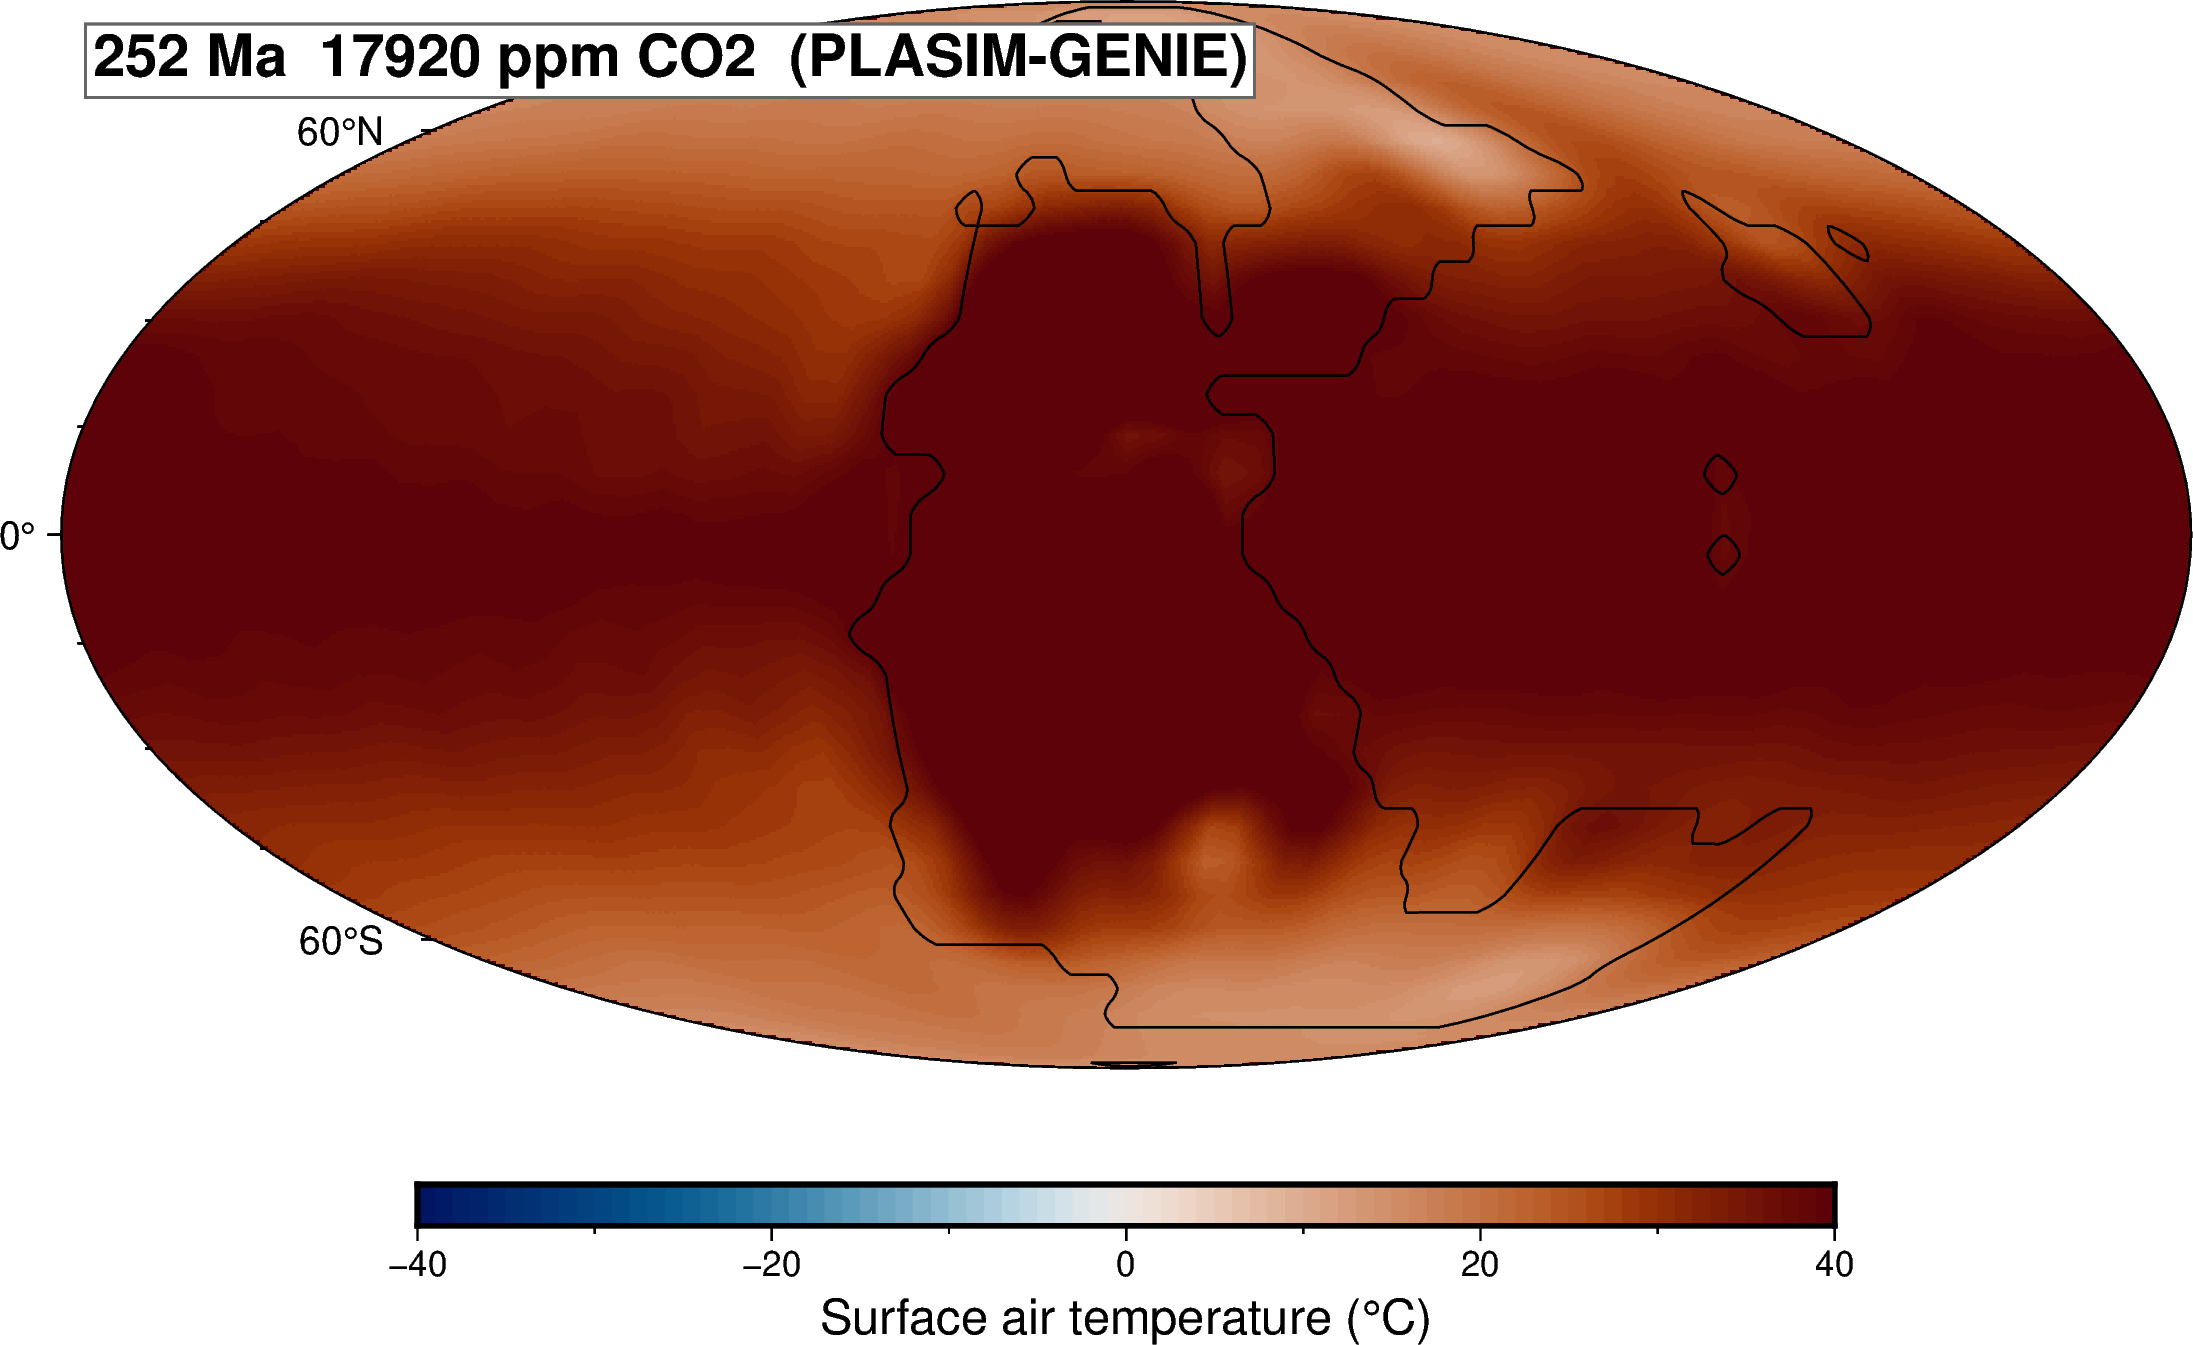

In [5]:
# Per-CO2 surface-air temperature maps
def _to_gmt(da):
    """Roll 0..360 → -180..180 and rename coords to lon/lat for refine_for_plot."""
    return (da.assign_coords(longitude=((da.longitude + 180) % 360 - 180))
              .sortby("longitude")
              .rename({"longitude": "lon", "latitude": "lat"}))

for co2 in CO2_PANEL_VALUES:
    sat_da = _to_gmt(ds["SAT"].sel(co2_ppm=co2))
    lsmask = _to_gmt(ds["landsea_mask"].sel(co2_ppm=co2))

    fig = pygmt.Figure()
    fig.basemap(region="d", projection="W0/18c", frame=["af"])
    pygmt.makecpt(cmap="vik", series=[SAT_RANGE[0], SAT_RANGE[1], 1], reverse=False, background="o")
    fig.grdimage(refine_for_plot(sat_da), cmap=True)
    fig.colorbar(frame="af+lSurface air temperature (°C)",
                 position="JBC+w12c/0.35c+h+o0/1c")
    # Model's own 252 Ma coastline = 0.5 contour of the PLASIM-GENIE land-sea
    # mask. NOT modern coastlines — this is the GCM's own paleogeography, which
    # is the frame the SAT field lives in.
    fig.grdcontour(refine_for_plot(lsmask), levels=[0.5], pen="0.5p,black")
    fig.text(text=f"{RECONSTRUCTION_TIME:.0f} Ma  {co2} ppm CO2  ({MODEL_NAME})",
             position="TL", offset="0.25c/-0.25c", justify="TL",
             font="14p,Helvetica-Bold,black",
             fill="white", pen="0.6p,gray40")
    fig.show(width=900)
    display(HTML('<div style="height:1cm"></div>'))

## 4. Zonal-mean SAT vs latitude — coloured by CO₂

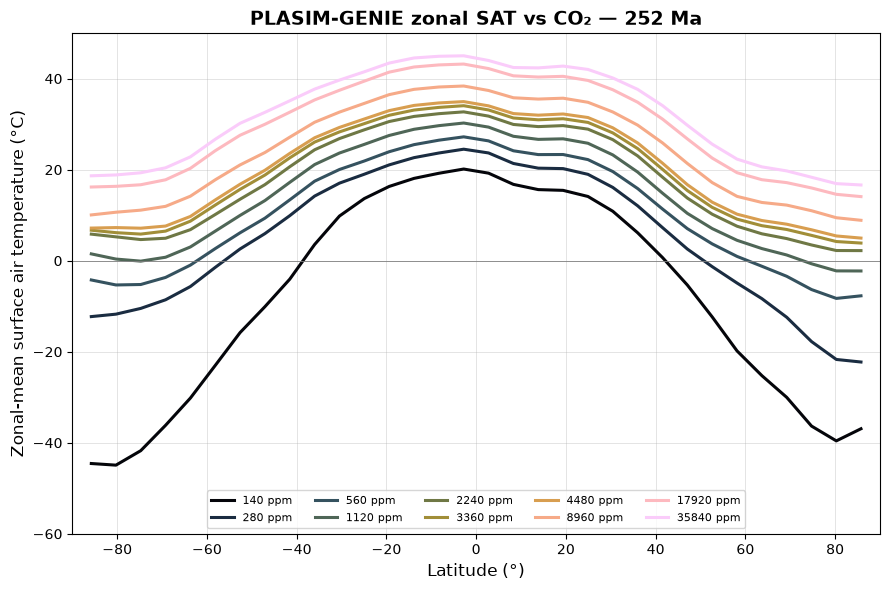

In [6]:
# Zonal-mean SAT vs latitude, coloured by CO2 (average over longitude at each latitude)
sat_zonal = ds["SAT"].mean(dim="longitude")  # (co2_ppm, lat)
lats      = ds["latitude"].values

fig, ax = plt.subplots(figsize=(9, 6))
for i, co2 in enumerate(ds.co2_ppm.values):
    color = base(norm_levels[i])
    ax.plot(lats, sat_zonal.isel(co2_ppm=i), lw=2.2, color=color, label=f"{co2} ppm")
ax.axhline(0, color="0.5", lw=0.6)
ax.set_xlabel("Latitude (°)", fontsize=12)
ax.set_ylabel("Zonal-mean surface air temperature (°C)", fontsize=12)
ax.set_title(f"PLASIM-GENIE zonal SAT vs CO₂ — {RECONSTRUCTION_TIME:.0f} Ma", fontsize=14, fontweight="bold")
ax.set_xlim(-90, 90); ax.set_ylim(-60, 50); ax.grid(True, lw=0.4, alpha=0.6)
ax.legend(loc="lower center", ncol=5, fontsize=8, frameon=True)
plt.tight_layout(); plt.show()

## 5. Climate sensitivity — GAST vs ln(CO₂)

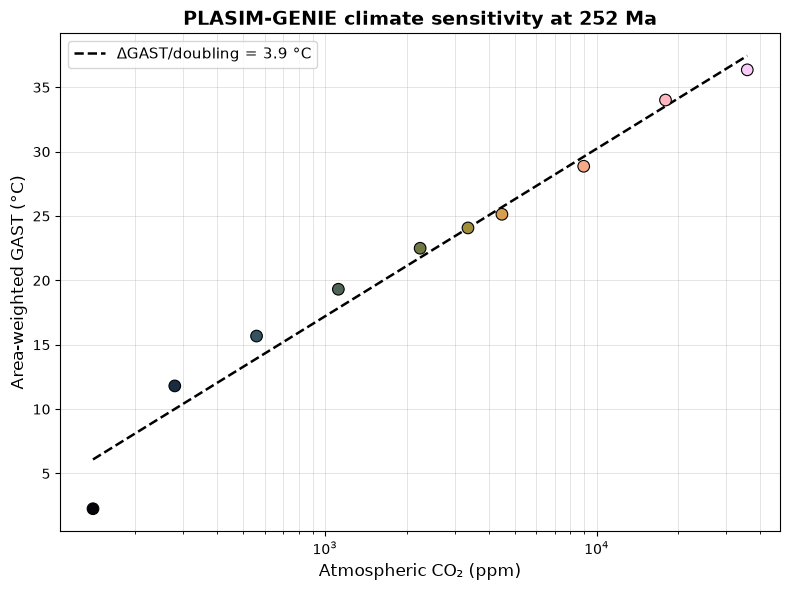


GAST range: 2.3°C (140 ppm) — 36.4°C (35840 ppm)
Logarithmic climate sensitivity: 3.92 °C per CO₂ doubling


/opt/miniconda3/envs/pyTUTORIALS/lib/python3.14/site-packages/xarray/core/dataarray.py:6325: FutureWarning: Behaviour of argmin/argmax with neither dim nor axis argument will change to return a dict of indices of each dimension. To get a single, flat index, please use np.argmin(da.data) or np.argmax(da.data) instead of da.argmin() or da.argmax().
  result = self.variable.argmin(dim, axis, keep_attrs, skipna)
/opt/miniconda3/envs/pyTUTORIALS/lib/python3.14/site-packages/xarray/core/dataarray.py:6446: FutureWarning: Behaviour of argmin/argmax with neither dim nor axis argument will change to return a dict of indices of each dimension. To get a single, flat index, please use np.argmin(da.data) or np.argmax(da.data) instead of da.argmin() or da.argmax().
  result = self.variable.argmax(dim, axis, keep_attrs, skipna)


In [7]:
# Climate sensitivity: GAST vs ln(CO2) scatter + fit
# Area-weighted GAST per CO2 level
weights = np.cos(np.deg2rad(lats))
weights_norm = weights / weights.sum()
gast = (ds["SAT"] * xr.DataArray(weights_norm, dims=("latitude",), coords={"latitude": lats})).sum(dim=("latitude","longitude")) / ds.sizes["longitude"]

# Linear regression: GAST = a + b * ln(CO2)
co2 = ds.co2_ppm.values.astype(float)
lnco2 = np.log(co2)
b, a = np.polyfit(lnco2, gast.values, 1)
ECS_per_doubling = b * np.log(2)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(co2, gast.values, s=70, c=norm_levels, cmap=cmc.batlowK,
           edgecolor="black", linewidth=0.8, zorder=3)
co2_line = np.geomspace(co2.min(), co2.max(), 200)
ax.plot(co2_line, a + b * np.log(co2_line),
        lw=1.8, color="black", ls="--",
        label=f"ΔGAST/doubling = {ECS_per_doubling:.1f} °C")
ax.set_xscale("log")
ax.set_xlabel("Atmospheric CO₂ (ppm)", fontsize=12)
ax.set_ylabel("Area-weighted GAST (°C)", fontsize=12)
ax.set_title(f"PLASIM-GENIE climate sensitivity at {RECONSTRUCTION_TIME:.0f} Ma", fontsize=14, fontweight="bold")
ax.grid(True, lw=0.4, alpha=0.6, which="both"); ax.legend(fontsize=11)
plt.tight_layout(); plt.show()

print(f"\nGAST range: {gast.values.min():.1f}°C ({co2[gast.argmin().item()]:.0f} ppm) — "
      f"{gast.values.max():.1f}°C ({co2[gast.argmax().item()]:.0f} ppm)")
print(f"Logarithmic climate sensitivity: {ECS_per_doubling:.2f} °C per CO₂ doubling")

## Extend this

- **Pull a different equilibrium variable.** The bundle includes `sea_ice_cover`, `snow_depth`, `surface_albedo`. Repeat the 3-panel map with `sea_ice_cover` to see the ice-margin retreat through the CO₂ sweep.
- **Different paleogeography ensemble.** Andrew Merdith maintains a full Cryogenian ensemble (575–800 Ma × 5 CO₂ × 4 paleogeography parameter sets). Same notebook framework; swap in those nc files and rerun.
- **Cross-reference T43.** T43 takes the same PLASIM-GENIE SAT field and projects it onto the reconstructed Permian paleo-Earth via GPlately. Together T44 + T43 show the CO₂ story (GCM-internal) and the paleogeographic story (reconstruction-frame) side-by-side.

## References

- Holden, P.B., Edwards, N.R., Fraedrich, K., Kirk, E., Lunkeit, F. & Zhu, X. (2016). PLASIM–GENIE v1.0: a new intermediate complexity AOGCM. *Geoscientific Model Development* 9, 3347–3361. https://doi.org/10.5194/gmd-9-3347-2016
- Fraedrich, K., Jansen, H., Kirk, E., Luksch, U., Lunkeit, F. (2005). The Planet Simulator: Towards a user friendly model. *Meteorologische Zeitschrift* 14, 299-304. (PLASIM atmosphere.)
- Edwards, N.R., Marsh, R. (2005). Uncertainties due to transport-parameter sensitivity in an efficient 3-D ocean-climate model. *Climate Dynamics* 24, 415-433. (GOLDSTEIN ocean.)
- Crameri, F. (2018). Scientific colour maps. *Zenodo*. (`cmcrameri` palette package.)
- Tian, D., Uieda, L., Leong, W.J., Fröhlich, Y., Schlitzer, W., Grund, M., Jones, M., Toney, L., Yao, J., Magen, Y., Tong, J.-H., Ngo, L., Materna, K., Belem, A., Newton, T., Anant, A., Ziebarth, M., Quinn, J. & Wessel, P. (2024). PyGMT: A Python interface for the Generic Mapping Tools. *Zenodo*. https://doi.org/10.5281/zenodo.13679420
- Wessel, P., Luis, J.F., Uieda, L., Scharroo, R., Wobbe, F., Smith, W.H.F. & Tian, D. (2019). The Generic Mapping Tools version 6. *Geochemistry, Geophysics, Geosystems* 20(11), 5556–5564. https://doi.org/10.1029/2019GC008515